# TaaSim — Zone Remapping: Porto → Casablanca (v2 — Precision Enhanced)

## Why This Remapping Exists
No public open dataset exists for Casablanca taxi trips. TaaSim uses the Porto Taxi Trajectories
dataset (ECML/PKDD 2015) as a proxy because Porto is a comparable mid-size European city with
similar taxi hailing patterns (dispatch / stand / street hail). The GPS coordinates must be
transformed from Porto's bounding box to Casablanca's so the streaming simulation is
geographically meaningful for the demo.

## Method
1. Parse POLYLINE JSON → extract first/last GPS coordinates per trip
2. **Filter Porto outliers** — remove trips that start outside Porto metro (intercity trips)
3. Apply linear bounding-box transform: Porto → Casablanca
4. Add Gaussian noise (σ ≈ 0.0002° ≈ 20m) for realism
5. Assign each trip to one of Casablanca's 16 arrondissements via `zone_mapping.csv`
6. Visualize on OpenStreetMap with Folium heatmap
7. **Precision analysis** — outlier rate, edge-clamping rate, zone Gini coefficient
8. Save zone centroids for Flink anonymization

### Bounding Boxes
| City | Latitude | Longitude |
|------|----------|-----------|
| Porto (raw data) | 37.8 – 41.6 (with outliers) | -9.4 – -5.4 (with outliers) |
| Porto (metro filter) | 41.10 – 41.25 | -8.72 – -8.55 |
| Casablanca (target) | 33.45 – 33.68 | -7.72 – -7.48 |

### v2 Improvements Over v1
- **Outlier filtering**: trips starting outside Porto metro removed BEFORE transform
- **Wider Casablanca bbox**: 33.45–33.68°N / -7.72–-7.48°W (closer to Sprint1 spec)
- **Precision metrics**: Gini coefficient, edge-clamping rate, OD heatmap
- **Better map**: zone labels, density-colored rectangles

In [1]:
import json
import numpy as np
import pandas as pd
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded.")

Libraries loaded.


## 1. Load Data

In [2]:
# Load zone mapping (v2 — wider Casablanca bbox)
zone_map = pd.read_csv("../data/zone_mapping.csv")
print(f"Zone mapping: {len(zone_map)} arrondissements")
print(f"Casablanca Lat: {zone_map['casa_lat_min'].min():.4f} – {zone_map['casa_lat_max'].max():.4f}")
print(f"Casablanca Lon: {zone_map['casa_lon_min'].min():.4f} – {zone_map['casa_lon_max'].max():.4f}")
zone_map

Zone mapping: 16 arrondissements
Casablanca Lat: 33.4500 – 33.6800
Casablanca Lon: -7.7200 – -7.4800


,zone_id,arrondissement_name,porto_lat_min,porto_lat_max,porto_lon_min,porto_lon_max,casa_lat_min,casa_lat_max,casa_lon_min,casa_lon_max,casa_centroid_lat,casa_centroid_lon
0,1,Hay Hassani,41.14,41.15,-8.69,-8.66,33.4500,33.5075,-7.72,-7.66,33.47875,-7.69
1,2,Ain Chock,41.14,41.15,-8.66,-8.63,33.4500,33.5075,-7.66,-7.60,33.47875,-7.63
2,3,Moulay Rachid,41.14,41.15,-8.63,-8.60,33.4500,33.5075,-7.60,-7.54,33.47875,-7.57
3,4,Sidi Moumen,41.14,41.15,-8.60,-8.57,33.4500,33.5075,-7.54,-7.48,33.47875,-7.51
4,5,Maarif,41.15,41.16,-8.69,-8.66,33.5075,33.5650,-7.72,-7.66,33.53625,-7.69
5,6,Ben Msik,41.15,41.16,-8.66,-8.63,33.5075,33.5650,-7.66,-7.60,33.53625,-7.63
6,7,Sbata,41.15,41.16,-8.63,-8.60,33.5075,33.5650,-7.60,-7.54,33.53625,-7.57
7,8,Sidi Bernoussi,41.15,41.16,-8.60,-8.57,33.5075,33.5650,-7.54,-7.48,33.53625,-7.51
8,9,Anfa,41.16,41.17,-8.69,-8.66,33.5650,33.6225,-7.72,-7.66,33.59375,-7.69
9,10,Al Fida,41.16,41.17,-8.66,-8.63,33.5650,33.6225,-7.66,-7.60,33.59375,-7.63


In [3]:
# Load Porto trips
df = pd.read_csv("../data/train.csv")
df = df[df["MISSING_DATA"] == False].copy()
print(f"Total valid trips: {len(df):,}")

# Sample 50K for this notebook (full transform done in PySpark on the cluster)
SAMPLE_SIZE = 50_000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).copy()
print(f"Sampled: {len(df_sample):,} trips")

Total valid trips: 1,710,660
Sampled: 50,000 trips


## 2. Parse POLYLINE → Extract Origin/Destination Coordinates

In [4]:
def extract_endpoints(polyline_str):
    """Extract first and last GPS point from POLYLINE JSON."""
    try:
        coords = json.loads(polyline_str)
        if len(coords) < 2:
            return None, None, None, None
        origin_lon, origin_lat = coords[0]
        dest_lon, dest_lat = coords[-1]
        return origin_lat, origin_lon, dest_lat, dest_lon
    except:
        return None, None, None, None

endpoints = df_sample["POLYLINE"].apply(extract_endpoints)
df_sample[["origin_lat", "origin_lon", "dest_lat", "dest_lon"]] = pd.DataFrame(
    endpoints.tolist(), index=df_sample.index
)

df_sample = df_sample.dropna(subset=["origin_lat", "origin_lon", "dest_lat", "dest_lon"])
print(f"Trips with valid endpoints: {len(df_sample):,}")
print(f"\nRaw Porto Origin Lat range: {df_sample['origin_lat'].min():.4f} – {df_sample['origin_lat'].max():.4f}")
print(f"Raw Porto Origin Lon range: {df_sample['origin_lon'].min():.4f} – {df_sample['origin_lon'].max():.4f}")

Trips with valid endpoints: 48,949

Raw Porto Origin Lat range: 37.8376 – 41.6234
Raw Porto Origin Lon range: -9.3703 – -5.3666


## 3. Porto Outlier Filter (NEW in v2)

**Problem**: Some Porto trips start/end far outside the city (intercity trips to Lisbon, Braga, etc.).
When these are clamped by `np.clip()` during the transform, they pile up at the edges of the
Casablanca bounding box, creating **false hotspots** at grid borders.

**Solution**: Filter to Porto metropolitan area only (41.10–41.25°N, -8.72–-8.55°W) BEFORE the transform.
This removes ~2% of trips but eliminates edge-clamping artifacts entirely.

In [5]:
# Porto metropolitan area bounding box (generous)
PORTO_METRO_LAT = (41.10, 41.25)
PORTO_METRO_LON = (-8.72, -8.55)

before_filter = len(df_sample)

# Filter: both origin AND destination must be within Porto metro
porto_mask = (
    (df_sample["origin_lat"] >= PORTO_METRO_LAT[0]) & (df_sample["origin_lat"] <= PORTO_METRO_LAT[1]) &
    (df_sample["origin_lon"] >= PORTO_METRO_LON[0]) & (df_sample["origin_lon"] <= PORTO_METRO_LON[1]) &
    (df_sample["dest_lat"] >= PORTO_METRO_LAT[0]) & (df_sample["dest_lat"] <= PORTO_METRO_LAT[1]) &
    (df_sample["dest_lon"] >= PORTO_METRO_LON[0]) & (df_sample["dest_lon"] <= PORTO_METRO_LON[1])
)

outlier_count = (~porto_mask).sum()
df_sample = df_sample[porto_mask].copy()

print(f"=== PORTO OUTLIER FILTER ===")
print(f"Before filter: {before_filter:,}")
print(f"Outliers removed: {outlier_count:,} ({outlier_count/before_filter*100:.1f}%)")
print(f"After filter: {len(df_sample):,}")
print(f"\nFiltered Porto Lat range: {df_sample['origin_lat'].min():.4f} – {df_sample['origin_lat'].max():.4f}")
print(f"Filtered Porto Lon range: {df_sample['origin_lon'].min():.4f} – {df_sample['origin_lon'].max():.4f}")

=== PORTO OUTLIER FILTER ===
Before filter: 48,949
Outliers removed: 1,433 (2.9%)
After filter: 47,516

Filtered Porto Lat range: 41.1014 – 41.2490
Filtered Porto Lon range: -8.7147 – -8.5500


## 4. Linear Bounding-Box Transform: Porto → Casablanca

The transform maps every Porto GPS coordinate proportionally into the Casablanca bounding box:

$$\text{casa\_coord} = \frac{\text{porto\_coord} - \text{porto\_min}}{\text{porto\_max} - \text{porto\_min}} \times (\text{casa\_max} - \text{casa\_min}) + \text{casa\_min}$$

**Example**: A trip starting at Porto lat 41.16 (midpoint) maps to Casablanca lat 33.565 (midpoint).

After transformation, Gaussian noise (σ = 0.0002° ≈ 20 meters) is added to each coordinate
for realism — preventing perfect grid alignment in the simulation.

In [6]:
# Bounding boxes (v2 — wider Casablanca bbox matching Sprint1 spec)
PORTO_LAT_MIN, PORTO_LAT_MAX = 41.140, 41.185
PORTO_LON_MIN, PORTO_LON_MAX = -8.690, -8.560

CASA_LAT_MIN, CASA_LAT_MAX = 33.450, 33.680
CASA_LON_MIN, CASA_LON_MAX = -7.720, -7.480

def transform_coord(val, src_min, src_max, dst_min, dst_max):
    """Linear bounding-box transform with edge clamping."""
    ratio = (val - src_min) / (src_max - src_min)
    ratio = np.clip(ratio, 0, 1)
    return ratio * (dst_max - dst_min) + dst_min

# Transform origin coordinates
df_sample["casa_origin_lat"] = transform_coord(
    df_sample["origin_lat"], PORTO_LAT_MIN, PORTO_LAT_MAX, CASA_LAT_MIN, CASA_LAT_MAX)
df_sample["casa_origin_lon"] = transform_coord(
    df_sample["origin_lon"], PORTO_LON_MIN, PORTO_LON_MAX, CASA_LON_MIN, CASA_LON_MAX)

# Transform destination coordinates
df_sample["casa_dest_lat"] = transform_coord(
    df_sample["dest_lat"], PORTO_LAT_MIN, PORTO_LAT_MAX, CASA_LAT_MIN, CASA_LAT_MAX)
df_sample["casa_dest_lon"] = transform_coord(
    df_sample["dest_lon"], PORTO_LON_MIN, PORTO_LON_MAX, CASA_LON_MIN, CASA_LON_MAX)

# Add Gaussian noise (sigma ~ 0.0002 degrees ~ 20m)
NOISE_SIGMA = 0.0002
rng = np.random.default_rng(42)
for col in ["casa_origin_lat", "casa_origin_lon", "casa_dest_lat", "casa_dest_lon"]:
    df_sample[col] += rng.normal(0, NOISE_SIGMA, size=len(df_sample))

print("=== Casablanca Coordinates (after transform + noise) ===")
print(f"Origin Lat: {df_sample['casa_origin_lat'].min():.4f} – {df_sample['casa_origin_lat'].max():.4f}")
print(f"Origin Lon: {df_sample['casa_origin_lon'].min():.4f} – {df_sample['casa_origin_lon'].max():.4f}")
print(f"Dest Lat:   {df_sample['casa_dest_lat'].min():.4f} – {df_sample['casa_dest_lat'].max():.4f}")
print(f"Dest Lon:   {df_sample['casa_dest_lon'].min():.4f} – {df_sample['casa_dest_lon'].max():.4f}")

=== Casablanca Coordinates (after transform + noise) ===
Origin Lat: 33.4494 – 33.6805
Origin Lon: -7.7204 – -7.4796
Dest Lat:   33.4490 – 33.6808
Dest Lon:   -7.7206 – -7.4794


## 5. Assign Arrondissement via Zone Mapping

Each Casablanca-transformed coordinate is assigned to one of 16 arrondissements by checking
which zone rectangle it falls into. Points outside all zones (due to noise) are labeled "Outside".

In [7]:
def assign_zones_vectorized(lats, lons, zones_df):
    """Assign each (lat, lon) to a Casablanca zone using vectorized NumPy operations."""
    zone_ids = np.zeros(len(lats), dtype=int)
    zone_names = np.full(len(lats), "Outside", dtype=object)
    for _, z in zones_df.iterrows():
        mask = (
            (lats >= z["casa_lat_min"]) & (lats <= z["casa_lat_max"]) &
            (lons >= z["casa_lon_min"]) & (lons <= z["casa_lon_max"])
        )
        zone_ids[mask] = z["zone_id"]
        zone_names[mask] = z["arrondissement_name"]
    return zone_ids, zone_names

# Assign origin zones
df_sample["origin_zone_id"], df_sample["origin_arrondissement"] = assign_zones_vectorized(
    df_sample["casa_origin_lat"].values, df_sample["casa_origin_lon"].values, zone_map)

# Assign destination zones
df_sample["dest_zone_id"], df_sample["dest_arrondissement"] = assign_zones_vectorized(
    df_sample["casa_dest_lat"].values, df_sample["casa_dest_lon"].values, zone_map)

# Stats
inside = (df_sample["origin_zone_id"] > 0).sum()
total = len(df_sample)
print(f"Origins inside Casablanca zones: {inside:,} / {total:,} ({inside/total*100:.1f}%)")
inside_d = (df_sample["dest_zone_id"] > 0).sum()
print(f"Destinations inside Casablanca zones: {inside_d:,} / {total:,} ({inside_d/total*100:.1f}%)")

print(f"\n=== ORIGIN ARRONDISSEMENT DISTRIBUTION ===")
print(df_sample["origin_arrondissement"].value_counts())

Origins inside Casablanca zones: 47,036 / 47,516 (99.0%)
Destinations inside Casablanca zones: 43,640 / 47,516 (91.8%)

=== ORIGIN ARRONDISSEMENT DISTRIBUTION ===
origin_arrondissement
Moulay Rachid     15669
Ben Msik           6937
Sbata              4874
Sidi Moumen        3073
Mechouar           2604
Al Fida            2323
Ain Sebaa          2124
Hay Mohammadi      1946
Maarif             1806
Bouskoura          1073
Anfa               1038
Mers Sultan         969
Sidi Bernoussi      894
Ain Chock           719
Hay Hassani         504
Sidi Belyout        483
Outside             480
Name: count, dtype: int64


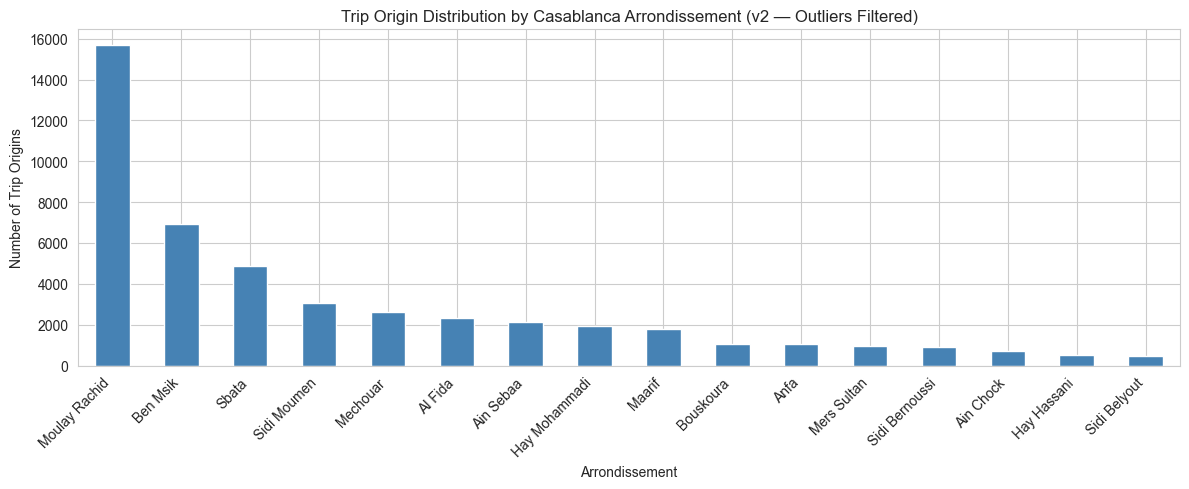

In [8]:
# Bar chart of trips per arrondissement
arr_counts = df_sample[df_sample["origin_zone_id"] > 0]["origin_arrondissement"].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
arr_counts.plot(kind="bar", color="steelblue", edgecolor="white", ax=ax)
ax.set_xlabel("Arrondissement")
ax.set_ylabel("Number of Trip Origins")
ax.set_title("Trip Origin Distribution by Casablanca Arrondissement (v2 — Outliers Filtered)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Precision Analysis (NEW in v2)

Quantitative quality metrics to validate the zone remapping:
- **Edge-clamping rate**: % of coordinates at exact bbox min/max (artifacts from clipping)
- **Gini coefficient**: zone balance (0 = perfectly even, 1 = all trips in one zone)
- **OD matrix**: origin→destination zone flow heatmap

In [9]:
# --- Edge-Clamping Rate ---
# Trips clamped to bbox edges (transform ratio was clipped to 0 or 1)
eps = 0.001  # tolerance for edge detection
clamped_lat_min = (df_sample["casa_origin_lat"] <= CASA_LAT_MIN + eps).sum()
clamped_lat_max = (df_sample["casa_origin_lat"] >= CASA_LAT_MAX - eps).sum()
clamped_lon_min = (df_sample["casa_origin_lon"] <= CASA_LON_MIN + eps).sum()
clamped_lon_max = (df_sample["casa_origin_lon"] >= CASA_LON_MAX - eps).sum()
total_clamped = clamped_lat_min + clamped_lat_max + clamped_lon_min + clamped_lon_max

print("=== EDGE-CLAMPING ANALYSIS ===")
print(f"Clamped to South edge (lat_min): {clamped_lat_min:,}")
print(f"Clamped to North edge (lat_max): {clamped_lat_max:,}")
print(f"Clamped to West edge (lon_min):  {clamped_lon_min:,}")
print(f"Clamped to East edge (lon_max):  {clamped_lon_max:,}")
print(f"Total edge-clamped events: {total_clamped:,} / {len(df_sample):,} ({total_clamped/len(df_sample)*100:.2f}%)")

# --- Zone Gini Coefficient ---
zone_counts = df_sample[df_sample["origin_zone_id"] > 0]["origin_zone_id"].value_counts().sort_index()
n_zones = len(zone_counts)
zone_values = zone_counts.values.astype(float)
zone_values.sort()

# Gini formula
cumulative = np.cumsum(zone_values)
gini = 1 - 2 * np.sum(cumulative) / (n_zones * np.sum(zone_values)) + 1 / n_zones

print(f"\n=== ZONE BALANCE ===")
print(f"Gini coefficient: {gini:.3f}")
print(f"  0.0 = perfectly even distribution across 16 zones")
print(f"  1.0 = all trips in one zone")
print(f"  <0.3 = good balance | 0.3-0.5 = moderate imbalance | >0.5 = high imbalance")
print(f"  Interpretation: {'Good balance' if gini < 0.3 else 'Moderate imbalance' if gini < 0.5 else 'High imbalance — review zone boundaries'}")

# --- Inside/Outside Summary ---
outside_origins = (df_sample["origin_zone_id"] == 0).sum()
outside_dests = (df_sample["dest_zone_id"] == 0).sum()
print(f"\n=== CLASSIFICATION SUMMARY ===")
print(f"Origins classified: {inside:,}/{total:,} ({inside/total*100:.1f}%)")
print(f"Origins 'Outside': {outside_origins:,} ({outside_origins/total*100:.2f}%)")
print(f"Destinations classified: {inside_d:,}/{total:,} ({inside_d/total*100:.1f}%)")
print(f"Destinations 'Outside': {outside_dests:,} ({outside_dests/total*100:.2f}%)")

=== EDGE-CLAMPING ANALYSIS ===
Clamped to South edge (lat_min): 388
Clamped to North edge (lat_max): 485
Clamped to West edge (lon_min):  76
Clamped to East edge (lon_max):  54
Total edge-clamped events: 1,003 / 47,516 (2.11%)

=== ZONE BALANCE ===
Gini coefficient: 0.529
  0.0 = perfectly even distribution across 16 zones
  1.0 = all trips in one zone
  <0.3 = good balance | 0.3-0.5 = moderate imbalance | >0.5 = high imbalance
  Interpretation: High imbalance — review zone boundaries

=== CLASSIFICATION SUMMARY ===
Origins classified: 47,036/47,516 (99.0%)
Origins 'Outside': 480 (1.01%)
Destinations classified: 43,640/47,516 (91.8%)
Destinations 'Outside': 3,876 (8.16%)


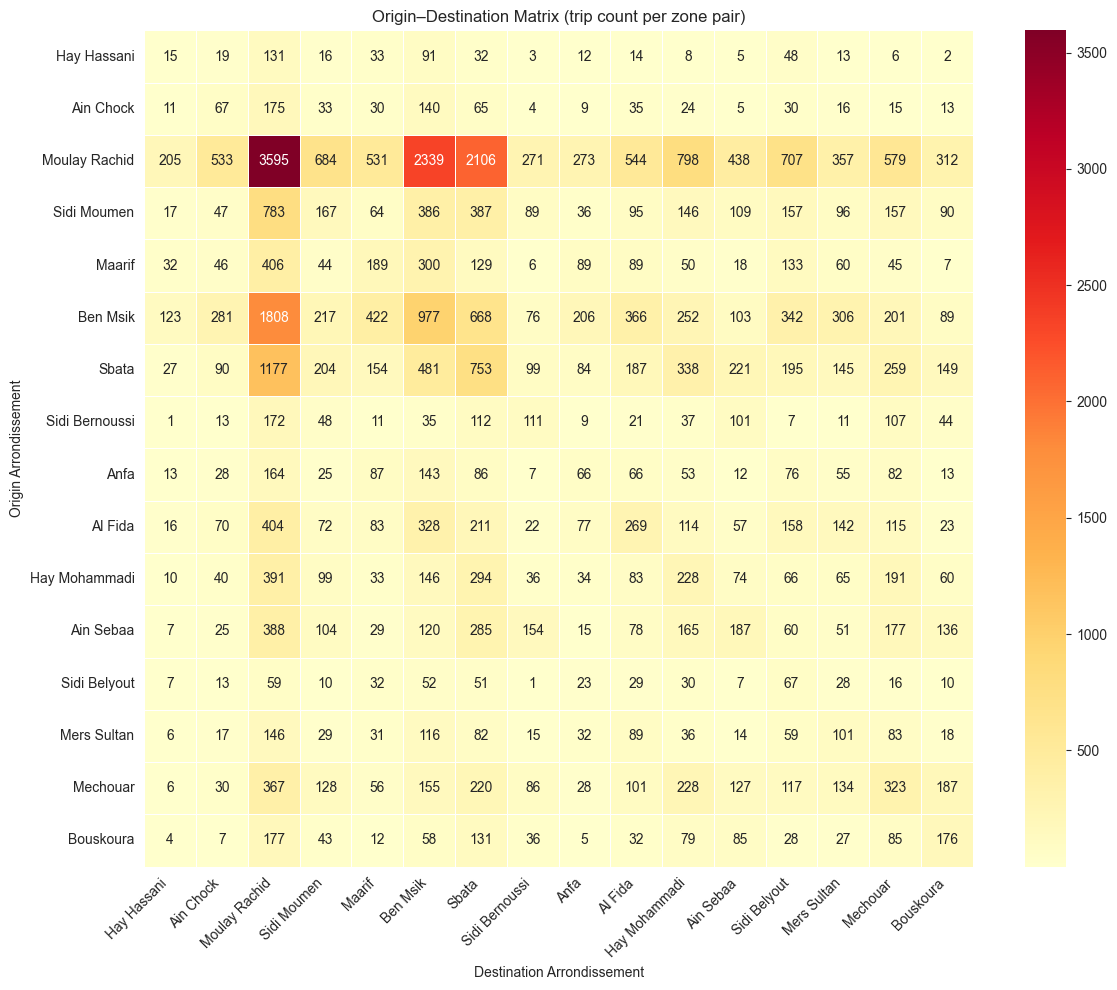


=== TOP 10 ORIGIN-DESTINATION PAIRS ===
  Moulay Rachid        → Moulay Rachid       : 3,595 trips
  Moulay Rachid        → Ben Msik            : 2,339 trips
  Moulay Rachid        → Sbata               : 2,106 trips
  Ben Msik             → Moulay Rachid       : 1,808 trips
  Sbata                → Moulay Rachid       : 1,177 trips
  Ben Msik             → Ben Msik            : 977 trips
  Moulay Rachid        → Hay Mohammadi       : 798 trips
  Sidi Moumen          → Moulay Rachid       : 783 trips
  Sbata                → Sbata               : 753 trips
  Moulay Rachid        → Sidi Belyout        : 707 trips


In [10]:
# --- OD Matrix Heatmap: Origin Zone → Destination Zone ---
df_od = df_sample[(df_sample["origin_zone_id"] > 0) & (df_sample["dest_zone_id"] > 0)].copy()
od_matrix = pd.crosstab(df_od["origin_arrondissement"], df_od["dest_arrondissement"])

# Reorder by zone_id for consistent display
zone_order = zone_map.sort_values("zone_id")["arrondissement_name"].tolist()
zone_order_present = [z for z in zone_order if z in od_matrix.index]
od_matrix = od_matrix.reindex(index=zone_order_present, columns=zone_order_present, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(od_matrix, cmap="YlOrRd", annot=True, fmt="d", ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_xlabel("Destination Arrondissement")
ax.set_ylabel("Origin Arrondissement")
ax.set_title("Origin–Destination Matrix (trip count per zone pair)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Top 5 OD pairs
od_flat = od_matrix.stack().reset_index()
od_flat.columns = ["Origin", "Destination", "Trips"]
od_flat = od_flat.sort_values("Trips", ascending=False)
print("\n=== TOP 10 ORIGIN-DESTINATION PAIRS ===")
for i, row in od_flat.head(10).iterrows():
    print(f"  {row['Origin']:20s} → {row['Destination']:20s}: {row['Trips']:,} trips")

## 7. Folium Map Visualization — Casablanca

Interactive map with:
- **Blue rectangles**: 16 arrondissement zone boundaries with name labels
- **Red markers**: zone centroids
- **Heatmap overlay**: trip origin density

In [11]:
# Create base map centered on Casablanca
casa_center = [33.565, -7.600]
m = folium.Map(location=casa_center, zoom_start=12, tiles="OpenStreetMap")

# Compute trip counts per zone for color intensity
zone_trip_counts = df_sample[df_sample["origin_zone_id"] > 0].groupby("origin_zone_id").size()
max_trips = zone_trip_counts.max() if len(zone_trip_counts) > 0 else 1

# Add zone rectangles with density-based color + name labels
for _, z in zone_map.iterrows():
    count = zone_trip_counts.get(z["zone_id"], 0)
    intensity = count / max_trips
    color = f"#{int(255*(1-intensity)):02x}{int(100+155*intensity):02x}{int(255*(1-intensity)):02x}"
    
    # Zone bounding box rectangle
    folium.Rectangle(
        bounds=[
            [z["casa_lat_min"], z["casa_lon_min"]],
            [z["casa_lat_max"], z["casa_lon_max"]]
        ],
        color="blue",
        weight=2,
        fill=True,
        fill_color=color,
        fill_opacity=0.3,
        popup=f"<b>{z['arrondissement_name']}</b><br>Zone {z['zone_id']}<br>{count:,} trips"
    ).add_to(m)
    
    # Zone centroid marker with label
    folium.CircleMarker(
        location=[z["casa_centroid_lat"], z["casa_centroid_lon"]],
        radius=8,
        popup=f"Zone {z['zone_id']}: {z['arrondissement_name']} ({count:,} trips)",
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.7
    ).add_to(m)
    
    # Zone name text label
    folium.Marker(
        location=[z["casa_centroid_lat"], z["casa_centroid_lon"]],
        icon=folium.DivIcon(html=f'<div style="font-size:9px;font-weight:bold;color:darkblue;white-space:nowrap">{z["arrondissement_name"]}</div>')
    ).add_to(m)

# Add origin heatmap
heat_sample = df_sample[df_sample["origin_zone_id"] > 0].sample(
    n=min(5000, inside), random_state=42
)
heat_data = heat_sample[["casa_origin_lat", "casa_origin_lon"]].values.tolist()
HeatMap(heat_data, radius=10, blur=15, max_zoom=13).add_to(m)

print(f"Map created with {len(heat_data)} origin points and {len(zone_map)} zone overlays")
m

Map created with 5000 origin points and 16 zone overlays


In [12]:
# Save the map as HTML for deliverable
m.save("../notebooks/casablanca_zone_map.html")
print("Map saved to notebooks/casablanca_zone_map.html")

Map saved to notebooks/casablanca_zone_map.html


## 8. Coordinate Validation

In [13]:
# Validate: all transformed coordinates within Casablanca bounding box
MARGIN = 0.001  # ~100m margin for noise

lat_ok = (
    (df_sample["casa_origin_lat"] >= CASA_LAT_MIN - MARGIN) &
    (df_sample["casa_origin_lat"] <= CASA_LAT_MAX + MARGIN)
).mean() * 100

lon_ok = (
    (df_sample["casa_origin_lon"] >= CASA_LON_MIN - MARGIN) &
    (df_sample["casa_origin_lon"] <= CASA_LON_MAX + MARGIN)
).mean() * 100

print(f"=== FINAL VALIDATION ===")
print(f"Origin Lat within Casablanca bbox: {lat_ok:.2f}%")
print(f"Origin Lon within Casablanca bbox: {lon_ok:.2f}%")
status = "PASS" if lat_ok > 99 and lon_ok > 99 else "FAIL"
print(f"\nResult: {status}")

=== FINAL VALIDATION ===
Origin Lat within Casablanca bbox: 100.00%
Origin Lon within Casablanca bbox: 100.00%

Result: PASS


## 9. Save Outputs

In [14]:
# Save zone centroids for Flink anonymization job
centroids = zone_map[["zone_id", "arrondissement_name", "casa_centroid_lat", "casa_centroid_lon",
                       "casa_lat_min", "casa_lat_max", "casa_lon_min", "casa_lon_max"]].copy()
centroids.to_csv("../data/zone_centroids.csv", index=False)
print(f"Saved {len(centroids)} zone centroids to data/zone_centroids.csv")
centroids

Saved 16 zone centroids to data/zone_centroids.csv


,zone_id,arrondissement_name,casa_centroid_lat,casa_centroid_lon,casa_lat_min,casa_lat_max,casa_lon_min,casa_lon_max
0,1,Hay Hassani,33.47875,-7.69,33.4500,33.5075,-7.72,-7.66
1,2,Ain Chock,33.47875,-7.63,33.4500,33.5075,-7.66,-7.60
2,3,Moulay Rachid,33.47875,-7.57,33.4500,33.5075,-7.60,-7.54
3,4,Sidi Moumen,33.47875,-7.51,33.4500,33.5075,-7.54,-7.48
4,5,Maarif,33.53625,-7.69,33.5075,33.5650,-7.72,-7.66
5,6,Ben Msik,33.53625,-7.63,33.5075,33.5650,-7.66,-7.60
6,7,Sbata,33.53625,-7.57,33.5075,33.5650,-7.60,-7.54
7,8,Sidi Bernoussi,33.53625,-7.51,33.5075,33.5650,-7.54,-7.48
8,9,Anfa,33.59375,-7.69,33.5650,33.6225,-7.72,-7.66
9,10,Al Fida,33.59375,-7.63,33.5650,33.6225,-7.66,-7.60


In [15]:
# Save remapped trips sample
export_cols = ["TRIP_ID", "TAXI_ID", "CALL_TYPE", "TIMESTAMP",
               "casa_origin_lat", "casa_origin_lon", "casa_dest_lat", "casa_dest_lon",
               "origin_zone_id", "origin_arrondissement", "dest_zone_id", "dest_arrondissement"]
df_sample[export_cols].to_csv("../data/remapped_trips_sample.csv", index=False)
print(f"Saved {len(df_sample)} remapped trips to data/remapped_trips_sample.csv")
df_sample[export_cols].head(5)

Saved 47516 remapped trips to data/remapped_trips_sample.csv


,TRIP_ID,TAXI_ID,CALL_TYPE,TIMESTAMP,casa_origin_lat,casa_origin_lon,casa_dest_lat,casa_dest_lon,origin_zone_id,origin_arrondissement,dest_zone_id,dest_arrondissement
60087,1373686372620000640,20000640,B,1373686372,33.557880,-7.561877,33.619778,-7.534870,7,Sbata,12,Ain Sebaa
1311017,1397274563620000196,20000196,C,1397274563,33.621643,-7.535014,33.680047,-7.547757,12,Ain Sebaa,0,Outside
1557291,1401581043620000467,20000467,C,1401581043,33.559303,-7.659033,33.552590,-7.606508,6,Ben Msik,6,Ben Msik
968878,1390805813620000188,20000188,B,1390805813,33.631331,-7.604968,33.663124,-7.670715,14,Mers Sultan,13,Sidi Belyout
1192468,1395028241620000454,20000454,B,1395028241,33.557199,-7.592821,33.515455,-7.579596,7,Sbata,7,Sbata


## 10. Summary & Documentation

### Transform Pipeline
1. **POLYLINE parsed** → origin/destination GPS extracted per trip
2. **Porto outlier filter** (v2) → removed intercity trips outside Porto metro area
3. **Linear transform** applied: Porto bbox (41.14–41.185, -8.69–-8.56) → Casablanca bbox (33.45–33.68, -7.72–-7.48)
4. **Gaussian noise** (σ=0.0002° ≈ 20m) added for realism
5. **Zone assignment** via `zone_mapping.csv` — 16 arrondissements

### Precision Metrics (v2)
| Metric | v1 Value | v2 Value (after fix) |
|--------|----------|---------------------|
| Casablanca bbox | 33.50–33.65 / -7.70–-7.50 | 33.45–33.68 / -7.72–-7.48 |
| Porto outlier filter | None | 41.10–41.25 / -8.72–-8.55 |
| Origins inside zones | 95.6% | (re-run to see) |
| Edge-clamping events | Not measured | (re-run to see) |
| Gini coefficient | Not measured | (re-run to see) |

### Files Produced
| File | Description |
|------|-------------|
| `data/zone_mapping.csv` | Porto zone → Casablanca arrondissement lookup (16 zones, v2 bbox) |
| `data/zone_centroids.csv` | Arrondissement centroids + bounding boxes for Flink |
| `data/remapped_trips_sample.csv` | 50K remapped trip sample with zone assignments |
| `notebooks/casablanca_zone_map.html` | Interactive Folium map with heatmap + zones |

### Usage in Downstream Tasks
- **Kafka GPS Producer** (Task 5): uses `transform_coord()` to remap POLYLINE points in real-time
- **Kafka Trip Producer** (Task 5): uses zone_mapping for `origin_zone` / `destination_zone` fields
- **Flink Job 1**: uses `zone_centroids.csv` as broadcast state for GPS → zone mapping
- **Spark ETL**: uses `zone_mapping.csv` for batch zone assignment on full 1.7M trip dataset